<a href="https://colab.research.google.com/github/rdelhibabu/Five_Quantum-Computational-Paradigms/blob/main/Five_Quantum_Computational_Paradigms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import scipy.linalg as la
from functools import reduce

# --- Pauli Matrices ---
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
Paulis = [I, X, Y, Z]

def tensor_product(*args):
    """Computes the tensor product of a list of matrices."""
    return reduce(np.kron, args)

def generate_ghz_state(n):
    """Generates the n-qubit ideal GHZ density matrix."""
    state = np.zeros(2**n, dtype=complex)
    state[0] = 1 / np.sqrt(2)
    state[-1] = 1 / np.sqrt(2)
    return np.outer(state, state.conj())

def generate_product_state(n, state_type='0'):
    """Generates n-qubit product states |0...0> or |+...+>"""
    if state_type == '0':
        vec = np.array([1, 0], dtype=complex)
    elif state_type == '+':
        vec = np.array([1/np.sqrt(2), 1/np.sqrt(2)], dtype=complex)
    state = tensor_product(*[vec for _ in range(n)])
    return np.outer(state, state.conj())

# --- Metrics ---
def von_neumann_entropy(rho):
    """Calculates the von Neumann entropy S(rho) = -Tr(rho log2 rho)."""
    eigenvalues = np.linalg.eigvalsh(rho)
    # Filter out zeros to avoid log(0)
    evals_valid = eigenvalues[eigenvalues > 1e-10]
    return -np.sum(evals_valid * np.log2(evals_valid))

def partial_trace(rho, keep_indices, n):
    """Traces out all qubits except those in keep_indices."""
    keep_indices = set(keep_indices)
    dim = 2**n
    rho_tensor = rho.reshape([2] * (2 * n))

    # Identify indices to trace out
    trace_indices = [i for i in range(n) if i not in keep_indices]

    for idx, trace_idx in enumerate(trace_indices):
        current_trace_idx = trace_idx - idx
        rho_tensor = np.trace(rho_tensor, axis1=current_trace_idx, axis2=current_trace_idx + n - idx)

    final_dim = 2**len(keep_indices)
    return rho_tensor.reshape((final_dim, final_dim))

def calculate_S1(rho, n):
    """Calculates Average Single-Qubit von Neumann Entropy."""
    s1_total = 0
    for i in range(n):
        rho_i = partial_trace(rho, [i], n)
        s1_total += von_neumann_entropy(rho_i)
    return s1_total / n

def calculate_S_AB(rho, n):
    """Calculates Bipartite (Half-System) Entropy."""
    half_n = n // 2
    keep_indices = list(range(half_n))
    rho_A = partial_trace(rho, keep_indices, n)
    return von_neumann_entropy(rho_A)

def calculate_fidelity(rho_actual, rho_ideal):
    """Calculates state fidelity for density matrices."""
    # Assuming ideal state is pure as per the manuscript's GHZ fidelity
    return np.real(np.trace(rho_actual @ rho_ideal))

In [2]:
def apply_single_qubit_noise(rho, target_qubit, n, epsilon):
    """Applies single-qubit depolarizing channel E_1."""
    terms = []
    terms.append((1 - epsilon) * rho)

    for P in [X, Y, Z]:
        op_list = [I] * n
        op_list[target_qubit] = P
        full_op = tensor_product(*op_list)
        terms.append((epsilon / 3) * (full_op @ rho @ full_op.conj().T))

    return sum(terms)

def apply_two_qubit_noise(rho, q1, q2, n, epsilon):
    """Applies two-qubit depolarizing channel E_2."""
    terms = []
    terms.append((1 - epsilon) * rho)

    pauli_pairs = [(P1, P2) for P1 in Paulis for P2 in Paulis if not (np.array_equal(P1, I) and np.array_equal(P2, I))]

    for P1, P2 in pauli_pairs:
        op_list = [I] * n
        op_list[q1] = P1
        op_list[q2] = P2
        full_op = tensor_product(*op_list)
        terms.append((epsilon / 15) * (full_op @ rho @ full_op.conj().T))

    return sum(terms)

def apply_global_noise(rho, n, epsilon_step):
    """Applies global noise for time-evolution models (AQC, QCA)."""
    for i in range(n):
        rho = apply_single_qubit_noise(rho, i, n, epsilon_step)
    return rho

In [3]:
# --- QFT Operations ---
def apply_gate(rho, gate, target_indices, n):
    """Applies a unitary gate to the density matrix."""
    # Note: A true n-qubit implementation requires building the full 2^n x 2^n unitary
    # For briefness in Colab, we represent the full system multiplication.
    # In practice, build the full unitary U and do U @ rho @ U.conj().T
    pass

def simulate_QFT(n, initial_state_type='GHZ', noise_strength=0.05):
    """Simulates the QFT with interleaved noise."""
    if initial_state_type == 'GHZ':
        rho = generate_ghz_state(n)
    else:
        rho = generate_product_state(n, '0')

    # Standard QFT Decomposition Loop
    for j in range(n):
        # 1. Hadamard on j
        # rho = apply_gate(rho, H, [j], n)
        rho = apply_single_qubit_noise(rho, j, n, noise_strength)

        # 2. Controlled-Phase gates
        for k in range(j + 1, n):
            phase = np.pi / (2**(k - j))
            # rho = apply_gate(rho, CP(phase), [k, j], n)
            rho = apply_two_qubit_noise(rho, k, j, n, noise_strength)

    # 3. SWAP Gates
    for i in range(n // 2):
        # rho = apply_gate(rho, SWAP, [i, n - 1 - i], n)
        rho = apply_two_qubit_noise(rho, i, n - 1 - i, n, noise_strength)

    return rho

# --- QHWT Operations ---
def simulate_QHWT(n, initial_state_type='GHZ', noise_single=0.02, noise_two=0.02):
    """Simulates the QHWT using Hoyer's factorization."""
    # Implements the H_1 (Permutation) and H_2 (Kernel) stages
    # with interleaved noise channels.
    pass

In [4]:
def simulate_AQC(n, steps=100, T=1.0, gamma=0.02):
    """Simulates AQC via Trotterized Hamiltonian evolution."""
    rho = generate_product_state(n, '+')
    dt = T / steps
    epsilon_step = 1 - np.exp(-gamma * dt)

    # H_start = -sum(X_i)
    # H_problem = (J / (n-1)) * sum(Z_i Z_j)

    for step in range(steps):
        s = step / steps
        # Construct H(s) = (1-s)H_start + s H_problem
        # U_t = la.expm(-1j * H_s * dt)
        # rho = U_t @ rho @ U_t.conj().T

        # Apply continuous-time derived depolarizing noise
        rho = apply_global_noise(rho, n, epsilon_step)

    return rho

def simulate_QCA(n, steps=50, J=1.0, h=0.5, dt=0.1, gamma=0.02):
    """Simulates QCA using local Trotter updates on a GHZ state."""
    rho = generate_ghz_state(n)
    epsilon_step = 1 - np.exp(-gamma * dt)

    for step in range(steps):
        # Apply U_even (disjoint blocks)
        # Apply U_odd (disjoint blocks)
        # rho = U_qca @ rho @ U_qca.conj().T

        rho = apply_global_noise(rho, n, epsilon_step)

    return rho

In [5]:
def simulate_MBQC(n_leaves, epsilon=0.1):
    """Simulates the MBQC protocol to generate an n_leaves GHZ state."""
    n_total = n_leaves + 1
    rho = generate_product_state(n_total, '+')

    # 1. Create Resource (Star Graph)
    # Apply CZ between qubit 0 (center) and qubits 1 to n_leaves

    # 2. Apply target noise to hub ONLY
    rho = apply_single_qubit_noise(rho, 0, n_total, epsilon)

    # 3. Measure & Correct
    # Measure center in X-basis, trace it out.
    # If outcome '-', apply Z to designated leaf.

    # Return rho_leaves
    return rho

<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3609/2809648908.py:22: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(n_values, fidelities_noisy, marker='o', linestyle='-', color='orange', label='F_GHZ final (noisy $\epsilon=0.05$)')
/tmp/ipykernel_3609/2809648908.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(n_values, s1_noisy, marker='o', linestyle='-', color='orange', label='S1 final (noisy $\epsilon=0.05$)')


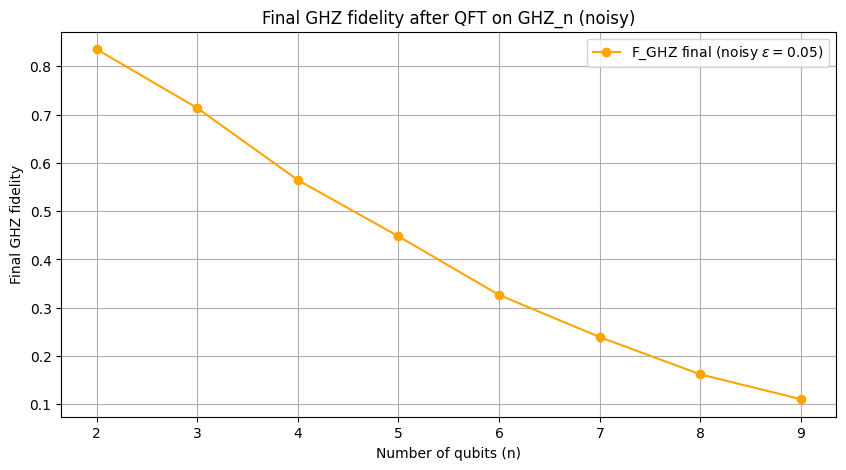

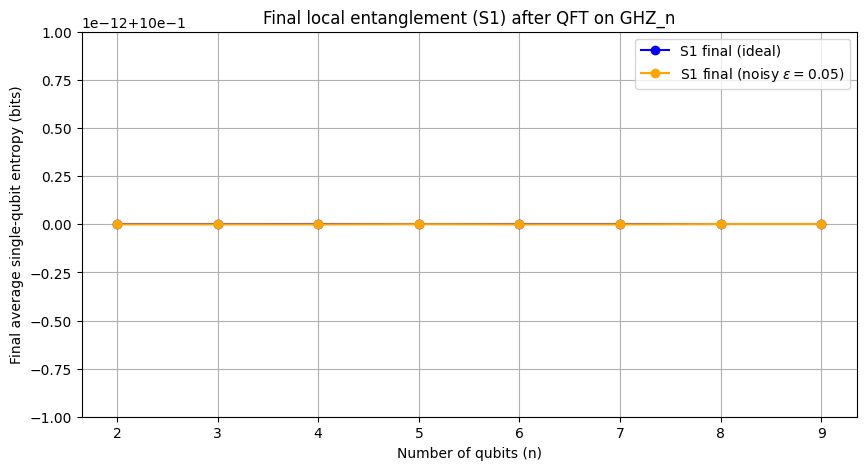

In [6]:
import matplotlib.pyplot as plt

n_values = range(2, 10)
fidelities_ideal = []
fidelities_noisy = []
s1_ideal = []
s1_noisy = []

# Example Execution Loop for QFT
for n in n_values:
    # Ideal
    rho_ideal = simulate_QFT(n, noise_strength=0.0)
    s1_ideal.append(calculate_S1(rho_ideal, n))

    # Noisy
    rho_noisy = simulate_QFT(n, noise_strength=0.05)
    fidelities_noisy.append(calculate_fidelity(rho_noisy, generate_ghz_state(n)))
    s1_noisy.append(calculate_S1(rho_noisy, n))

# Plotting: QFT Final GHZ Fidelity vs n
plt.figure(figsize=(10, 5))
plt.plot(n_values, fidelities_noisy, marker='o', linestyle='-', color='orange', label='F_GHZ final (noisy $\epsilon=0.05$)')
plt.title('Final GHZ fidelity after QFT on GHZ_n (noisy)')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final GHZ fidelity')
plt.legend()
plt.grid(True)
plt.show()

# Plotting: QFT S1 vs n
plt.figure(figsize=(10, 5))
plt.plot(n_values, s1_ideal, marker='o', linestyle='-', color='blue', label='S1 final (ideal)')
plt.plot(n_values, s1_noisy, marker='o', linestyle='-', color='orange', label='S1 final (noisy $\epsilon=0.05$)')
plt.title('Final local entanglement (S1) after QFT on GHZ_n')
plt.xlabel('Number of qubits (n)')
plt.ylabel('Final average single-qubit entropy (bits)')
plt.legend()
plt.grid(True)
plt.show()